# 08i — Evidence Integration and Bayesian-Optimisation Readiness

This notebook integrates observed evidence from 08f (endpoint energy), 08g (structural validation) and 08h (sequence-derived developability or verified CamSol results). It keeps raw metrics, directions and provenance visible.

With only two evaluated candidates, the current run is an exploratory decision-support analysis—not a statistically mature Bayesian-optimisation campaign. No Gaussian process, acquisition function, affinity value or new sequence is fabricated.

## 1. Configuration

`PROJECT_ROOT` is the directory containing the pipeline `outputs` folder. Change it only if the project is moved. The minimum observation count is a conservative workflow safeguard, not a universal statistical threshold. Passing it would still not guarantee that Bayesian optimisation is appropriate.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/Users/robertobruzzese/Desktop/venv')
OUTPUTS_ROOT = PROJECT_ROOT / 'outputs'

P08F = OUTPUTS_ROOT / 'pipeline_4_ai_08f_endpoint_energy/production_50snap/tables/08f_ProteinMPNN_cross_method_evidence.csv'
P08G = OUTPUTS_ROOT / 'pipeline_4_ai_08g_esmfold_structural_validation/tables/08g_ESMFold_structural_validation_summary.csv'
P08H = OUTPUTS_ROOT / 'pipeline_4_ai_08h_solubility_developability/tables/08h_solubility_developability_summary.csv'

OUTPUT_ROOT = OUTPUTS_ROOT / 'pipeline_4_ai_08i_bayesian_optimisation'
TABLE_DIR = OUTPUT_ROOT / 'tables'
FIGURE_DIR = OUTPUT_ROOT / 'figures'
PROVENANCE_DIR = OUTPUT_ROOT / 'provenance'
for directory in (TABLE_DIR, FIGURE_DIR, PROVENANCE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MIN_OBSERVATIONS_FOR_BO = 8
ENABLE_BOTORCH = False
CANDIDATE_POOL = None  # Future CSV: unevaluated sequences plus numerical feature columns.
RANDOM_SEED = 20260824
RUN_TIMESTAMP_UTC = datetime.now(timezone.utc).isoformat()

for label, path in {'08f': P08F, '08g': P08G, '08h': P08H}.items():
    print(label, '->', path, '| exists:', path.exists())

08f -> /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08f_endpoint_energy/production_50snap/tables/08f_ProteinMPNN_cross_method_evidence.csv | exists: True
08g -> /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08g_esmfold_structural_validation/tables/08g_ESMFold_structural_validation_summary.csv | exists: True
08h -> /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08h_solubility_developability/tables/08h_solubility_developability_summary.csv | exists: True


## 2. Load and validate the three evidence contracts

All inputs are mandatory for the declared integration. Candidate cohorts must match exactly; duplicate IDs, missing sequences and sequence disagreements are blocking errors. A sequence hash is computed when an upstream table does not yet provide one.

In [2]:
input_paths = {'08f': P08F, '08g': P08G, '08h': P08H}
missing_files = [f'{name}: {path}' for name, path in input_paths.items() if not path.exists()]
if missing_files:
    raise FileNotFoundError('Required 08i inputs are missing:\n' + '\n'.join(missing_files))

def normalize_sequence(series):
    if series.isna().any():
        raise ValueError('Null sequence detected')
    return series.astype(str).str.upper().str.replace(r'\s+', '', regex=True)

def prepare_input(path, source_name):
    frame = pd.read_csv(path)
    required = {'candidate_id', 'sequence'}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f'{source_name} lacks columns: {sorted(missing)}')
    if frame['candidate_id'].isna().any():
        raise ValueError(f'{source_name} contains null candidate_id')
    frame['candidate_id'] = frame['candidate_id'].astype(str).str.strip()
    frame['sequence'] = normalize_sequence(frame['sequence'])
    if frame['candidate_id'].eq('').any() or frame['sequence'].eq('').any():
        raise ValueError(f'{source_name} contains empty candidate_id or sequence')
    if frame['candidate_id'].duplicated().any():
        duplicated = frame.loc[frame['candidate_id'].duplicated(False), 'candidate_id'].tolist()
        raise ValueError(f'{source_name} contains duplicated IDs: {duplicated}')
    calculated_hash = frame['sequence'].map(
        lambda sequence: hashlib.sha256(sequence.encode('utf-8')).hexdigest()
    )
    if 'sequence_sha256' in frame.columns:
        mismatch = frame['sequence_sha256'].astype(str).ne(calculated_hash)
        if mismatch.any():
            bad = frame.loc[mismatch, 'candidate_id'].tolist()
            raise ValueError(f'{source_name} sequence hash mismatch: {bad}')
    frame['sequence_sha256'] = calculated_hash
    return frame

f08 = prepare_input(P08F, '08f')
g08 = prepare_input(P08G, '08g')
h08 = prepare_input(P08H, '08h')

expected_ids = set(f08['candidate_id'])
for source_name, frame in [('08g', g08), ('08h', h08)]:
    observed_ids = set(frame['candidate_id'])
    if observed_ids != expected_ids:
        raise ValueError(
            f'{source_name} candidate cohort differs from 08f; '
            f'missing={sorted(expected_ids-observed_ids)}, extra={sorted(observed_ids-expected_ids)}'
        )

identity = f08[['candidate_id', 'sequence', 'sequence_sha256']].copy()
for source_name, frame in [('08g', g08), ('08h', h08)]:
    check = identity.merge(
        frame[['candidate_id', 'sequence', 'sequence_sha256']],
        on='candidate_id', how='left', validate='one_to_one',
        suffixes=('_08f', f'_{source_name}'),
    )
    mismatch = (
        check['sequence_08f'].ne(check[f'sequence_{source_name}'])
        | check['sequence_sha256_08f'].ne(check[f'sequence_sha256_{source_name}'])
    )
    if mismatch.any():
        raise ValueError(f'Sequence disagreement between 08f and {source_name}: ' + ', '.join(check.loc[mismatch, 'candidate_id']))

print('Validated candidates:', sorted(expected_ids))

Validated candidates: ['MPNN_NEW_01', 'MPNN_NEW_05']


## 3. Select evidence without silently dropping duplicate columns

The integrated table retains raw values and provenance. Endpoint energy is treated as lower-is-better, pLDDT as higher-is-better, RMSD as lower-is-better, and the developability direction is read from 08h rather than assumed. Structural confidence and reference agreement are first combined into a structural-domain signal so that structure is not double-weighted merely because it has two columns.

In [3]:
required_08f = {
    'mean_delta_E_endpoint_kcal_mol', 'sd_delta_E_endpoint_kcal_mol'
}
required_08g = {
    'mean_pLDDT', 'global_CA_RMSD_A', 'reference_comparison_status',
    'sequence_matches_expected', 'pLDDT_valid',
}
required_08h = {
    'developability_metric_value', 'developability_metric_higher_is_better',
    'developability_metric_used', 'developability_metric_source',
    'camsol_executed', 'camsol_result_validated', 'camsol_overall_score',
}
for source_name, frame, required in [
    ('08f', f08, required_08f), ('08g', g08, required_08g), ('08h', h08, required_08h)
]:
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f'{source_name} lacks required columns: {sorted(missing)}')

f_cols = [
    'candidate_id', 'sequence', 'sequence_sha256',
    'mean_delta_E_endpoint_kcal_mol', 'sd_delta_E_endpoint_kcal_mol',
]
for optional in [
    'AI_integrated_score', 'ESM2_PLL_mean', 'best_ProteinMPNN_score',
    'foldx_interaction_energy_kcal_mol', 'best_I_sc',
    'mean_peptide_CA_RMSD_A', 'mean_peptide_CA_RMSF_A',
    'n_persistent_contacts_50pct', 'mean_contact_persistence',
]:
    if optional in f08.columns:
        f_cols.append(optional)

g_cols = [
    'candidate_id', 'mean_pLDDT', 'median_pLDDT', 'min_pLDDT',
    'fraction_pLDDT_ge_70', 'pLDDT_valid',
    'reference_comparison_status', 'global_CA_RMSD_A',
    'global_backbone_RMSD_after_CA_fit_A',
    'protected_CA_RMSD_after_global_fit_A',
    'protected_CA_RMSD_local_fit_A', 'reference_mapping_coverage',
    'sequence_matches_expected',
]
g_cols = [column for column in g_cols if column in g08.columns]

h_cols = [
    'candidate_id', 'proxy_gravy', 'proxy_charge_at_pH7',
    'proxy_isoelectric_point', 'proxy_instability_index',
    'proxy_heuristic_alerts', 'camsol_executed',
    'camsol_result_validated', 'camsol_mode', 'camsol_version',
    'camsol_overall_score', 'developability_metric_used',
    'developability_metric_source',
    'developability_metric_higher_is_better',
    'developability_metric_value',
]
h_cols = [column for column in h_cols if column in h08.columns]

df = f08[f_cols].merge(
    g08[g_cols], on='candidate_id', how='inner', validate='one_to_one'
).merge(
    h08[h_cols], on='candidate_id', how='inner', validate='one_to_one'
)

numeric_required = [
    'mean_delta_E_endpoint_kcal_mol', 'sd_delta_E_endpoint_kcal_mol',
    'mean_pLDDT', 'global_CA_RMSD_A', 'developability_metric_value',
]
for column in numeric_required:
    df[column] = pd.to_numeric(df[column], errors='raise')
if not np.isfinite(df[numeric_required].to_numpy(dtype=float)).all():
    raise ValueError('Required objective values contain NaN or infinity')

direction_values = h08['developability_metric_higher_is_better'].dropna().unique()
if len(direction_values) != 1:
    raise ValueError('08h developability direction must be identical and explicit for the complete cohort')
developability_higher_is_better = bool(direction_values[0])
display(df)

,candidate_id,sequence,sequence_sha256,mean_delta_E_endpoint_kcal_mol,sd_delta_E_endpoint_kcal_mol,AI_integrated_score,ESM2_PLL_mean,best_ProteinMPNN_score,foldx_interaction_energy_kcal_mol,best_I_sc,...,proxy_heuristic_alerts,camsol_executed,camsol_result_validated,camsol_mode,camsol_version,camsol_overall_score,developability_metric_used,developability_metric_source,developability_metric_higher_is_better,developability_metric_value
0,MPNN_NEW_01,TGPRNQYRDLP,2aabd4dfdefe34755b3409eb7c510495268239b597adac...,-46.408438,4.655577,0.601249,-3.172003,1.2473,-11.7407,-54.169,...,NaN,False,False,NaN,NaN,NaN,proxy_gravy,sequence-derived Biopython GRAVY proxy,False,-1.936364
1,MPNN_NEW_05,IGPRHQYRDLP,2c7e843423076b0f54d2ed351fcbdf120d8cb3d3a5da9c...,-53.673748,6.427169,0.508830,-3.174593,1.4079,-13.7478,-56.118,...,NaN,False,False,NaN,NaN,NaN,proxy_gravy,sequence-derived Biopython GRAVY proxy,False,-1.436364


## 4. Direction-aware exploratory utilities

Z-scores are calculated only within this observed cohort. With two observations they encode ordering far more than effect magnitude; therefore raw values remain authoritative and the composite is explicitly labelled exploratory. Equal domain weights are configurable and reported.

In [4]:
def utility_z(series, higher_is_better):
    values = pd.to_numeric(series, errors='coerce')
    result = pd.Series(np.nan, index=values.index, dtype=float)
    valid = values.notna() & np.isfinite(values)
    if valid.sum() < 2:
        return result
    scale = values.loc[valid].std(ddof=0)
    if scale == 0:
        result.loc[valid] = 0.0
    else:
        result.loc[valid] = (values.loc[valid] - values.loc[valid].mean()) / scale
    return result if higher_is_better else -result

df['energy_utility_z'] = utility_z(
    df['mean_delta_E_endpoint_kcal_mol'], higher_is_better=False
)
df['plddt_utility_z'] = utility_z(df['mean_pLDDT'], higher_is_better=True)
df['global_rmsd_utility_z'] = utility_z(df['global_CA_RMSD_A'], higher_is_better=False)
df['structural_utility_z'] = df[['plddt_utility_z', 'global_rmsd_utility_z']].mean(
    axis=1, skipna=False
)
df['developability_utility_z'] = utility_z(
    df['developability_metric_value'],
    higher_is_better=developability_higher_is_better,
)

DOMAIN_WEIGHTS = {
    'energy_utility_z': 1 / 3,
    'structural_utility_z': 1 / 3,
    'developability_utility_z': 1 / 3,
}
if not np.isclose(sum(DOMAIN_WEIGHTS.values()), 1.0):
    raise ValueError('Domain weights must sum to one')

df['observed_composite_proxy'] = sum(
    weight * df[column] for column, weight in DOMAIN_WEIGHTS.items()
)
df['exploratory_rank'] = df['observed_composite_proxy'].rank(
    ascending=False, method='min', na_option='bottom'
).astype('Int64')

evidence_columns = [
    'exploratory_rank', 'candidate_id', 'sequence',
    'mean_delta_E_endpoint_kcal_mol', 'sd_delta_E_endpoint_kcal_mol',
    'mean_pLDDT', 'global_CA_RMSD_A',
    'developability_metric_value', 'developability_metric_used',
    'developability_metric_source', 'energy_utility_z',
    'structural_utility_z', 'developability_utility_z',
    'observed_composite_proxy',
]
display(df[evidence_columns].sort_values('exploratory_rank'))

,exploratory_rank,candidate_id,sequence,mean_delta_E_endpoint_kcal_mol,sd_delta_E_endpoint_kcal_mol,mean_pLDDT,global_CA_RMSD_A,developability_metric_value,developability_metric_used,developability_metric_source,energy_utility_z,structural_utility_z,developability_utility_z,observed_composite_proxy
0,1,MPNN_NEW_01,TGPRNQYRDLP,-46.408438,4.655577,72.559091,4.486997,-1.936364,proxy_gravy,sequence-derived Biopython GRAVY proxy,-1.0,1.0,1.0,0.333333
1,2,MPNN_NEW_05,IGPRHQYRDLP,-53.673748,6.427169,67.273636,5.073322,-1.436364,proxy_gravy,sequence-derived Biopython GRAVY proxy,1.0,-1.0,-1.0,-0.333333


## 5. Weight-sensitivity analysis

A two-candidate composite can change when subjective domain weights change. The scenarios below expose that dependence instead of presenting one weighting as uniquely correct.

In [5]:
WEIGHT_SCENARIOS = {
    'equal_domains': {'energy': 1/3, 'structure': 1/3, 'developability': 1/3},
    'energy_priority': {'energy': 0.50, 'structure': 0.25, 'developability': 0.25},
    'structure_priority': {'energy': 0.25, 'structure': 0.50, 'developability': 0.25},
    'developability_priority': {'energy': 0.25, 'structure': 0.25, 'developability': 0.50},
}
sensitivity_rows = []
for scenario, weights in WEIGHT_SCENARIOS.items():
    if not np.isclose(sum(weights.values()), 1.0):
        raise ValueError(f'Weights do not sum to one: {scenario}')
    scores = (
        weights['energy'] * df['energy_utility_z']
        + weights['structure'] * df['structural_utility_z']
        + weights['developability'] * df['developability_utility_z']
    )
    ranks = scores.rank(ascending=False, method='min', na_option='bottom').astype('Int64')
    for index, row in df.iterrows():
        sensitivity_rows.append({
            'scenario': scenario,
            'candidate_id': row['candidate_id'],
            'weight_energy': weights['energy'],
            'weight_structure': weights['structure'],
            'weight_developability': weights['developability'],
            'composite_score': scores.loc[index],
            'rank': ranks.loc[index],
        })
sensitivity = pd.DataFrame(sensitivity_rows)
winner_counts = (
    sensitivity.loc[sensitivity['rank'].eq(1)]
    .groupby('candidate_id')['scenario'].nunique()
    .rename('n_scenarios_ranked_first')
    .reset_index()
)
display(sensitivity.sort_values(['scenario', 'rank', 'candidate_id']))
display(winner_counts)

,scenario,candidate_id,weight_energy,weight_structure,weight_developability,composite_score,rank
6,developability_priority,MPNN_NEW_01,0.250000,0.250000,0.500000,5.000000e-01,1
7,developability_priority,MPNN_NEW_05,0.250000,0.250000,0.500000,-5.000000e-01,2
2,energy_priority,MPNN_NEW_01,0.500000,0.250000,0.250000,3.330669e-16,1
3,energy_priority,MPNN_NEW_05,0.500000,0.250000,0.250000,3.330669e-16,1
0,equal_domains,MPNN_NEW_01,0.333333,0.333333,0.333333,3.333333e-01,1
1,equal_domains,MPNN_NEW_05,0.333333,0.333333,0.333333,-3.333333e-01,2
4,structure_priority,MPNN_NEW_01,0.250000,0.500000,0.250000,5.000000e-01,1
5,structure_priority,MPNN_NEW_05,0.250000,0.500000,0.250000,-5.000000e-01,2


,candidate_id,n_scenarios_ranked_first
0,MPNN_NEW_01,4
1,MPNN_NEW_05,1


## 6. Bayesian-optimisation readiness gate

BoTorch is not used merely because it can be imported. A run additionally requires enough evaluated observations, a non-empty unevaluated candidate pool, explicit numerical features and deliberate activation. The current two-candidate dataset fails the observation-count gate, so no model or proposal is produced.

In [6]:
try:
    import torch
    import botorch
    BOTORCH_AVAILABLE = True
    BOTORCH_VERSION = botorch.__version__
except Exception as exc:
    BOTORCH_AVAILABLE = False
    BOTORCH_VERSION = None
    BOTORCH_IMPORT_MESSAGE = str(exc)

candidate_pool_available = CANDIDATE_POOL is not None and Path(CANDIDATE_POOL).exists()
readiness_checks = pd.DataFrame([
    {'requirement': 'manual_activation', 'pass': bool(ENABLE_BOTORCH), 'details': f'ENABLE_BOTORCH={ENABLE_BOTORCH}'},
    {'requirement': 'botorch_available', 'pass': bool(BOTORCH_AVAILABLE), 'details': str(BOTORCH_VERSION or globals().get('BOTORCH_IMPORT_MESSAGE', ''))},
    {'requirement': 'minimum_observations', 'pass': len(df) >= MIN_OBSERVATIONS_FOR_BO, 'details': f'n={len(df)}, minimum={MIN_OBSERVATIONS_FOR_BO}'},
    {'requirement': 'unevaluated_candidate_pool', 'pass': bool(candidate_pool_available), 'details': str(CANDIDATE_POOL)},
    {'requirement': 'complete_observed_objectives', 'pass': bool(df[list(DOMAIN_WEIGHTS)].notna().all().all()), 'details': ''},
])
bo_ready = bool(readiness_checks['pass'].all())

if bo_ready:
    # Intentionally blocked until a feature schema and candidate-pool contract
    # are reviewed for the expanded dataset. Passing generic readiness checks
    # is not sufficient authority to invent a modelling specification.
    bo_status = 'blocked_pending_feature_and_model_specification'
    proposal_reason = 'Generic gates passed, but an approved feature/model specification is still required'
else:
    bo_status = 'not_run_readiness_requirements_not_met'
    failed = readiness_checks.loc[~readiness_checks['pass'], 'requirement'].tolist()
    proposal_reason = 'Failed readiness requirements: ' + ', '.join(failed)

proposal = pd.DataFrame([{
    'bo_status': bo_status,
    'candidate_id': pd.NA,
    'sequence': pd.NA,
    'acquisition_function': pd.NA,
    'acquisition_value': np.nan,
    'reason': proposal_reason,
}])
display(readiness_checks)
display(proposal)

,requirement,pass,details
0,manual_activation,False,ENABLE_BOTORCH=False
1,botorch_available,False,No module named 'botorch'
2,minimum_observations,False,"n=2, minimum=8"
3,unevaluated_candidate_pool,False,None
4,complete_observed_objectives,True,


,bo_status,candidate_id,sequence,acquisition_function,acquisition_value,reason
0,not_run_readiness_requirements_not_met,<NA>,<NA>,<NA>,NaN,Failed readiness requirements: manual_activati...


## 7. Quality control and outputs

,check,pass,details
0,all_required_inputs_exist,True,
1,candidate_cohorts_identical,True,n=2
2,candidate_ids_unique,True,
3,sequences_and_hashes_validated,True,
4,08g_sequence_and_plddt_valid,True,
5,reference_comparisons_completed,True,
6,required_objectives_finite,True,
7,developability_provenance_explicit,True,sequence-derived Biopython GRAVY proxy
8,camsol_state_consistent,True,CamSol may legitimately be not executed
9,weights_sum_to_one,True,"{""energy_utility_z"": 0.3333333333333333, ""stru..."


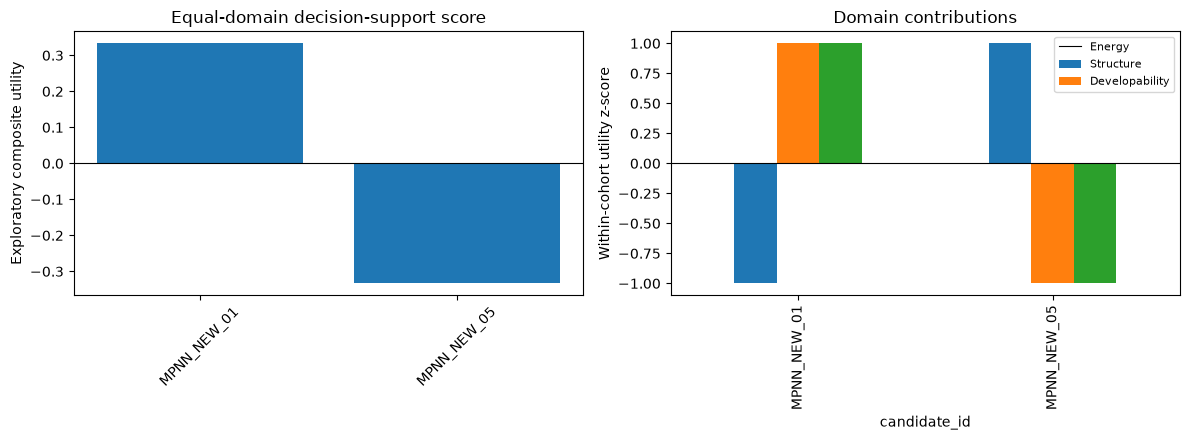

ALL QC PASSED: True
Bayesian-optimisation status: not_run_readiness_requirements_not_met
Integrated evidence: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08i_bayesian_optimisation/tables/08i_observed_integrated_evidence.csv
Exploratory ranking: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08i_bayesian_optimisation/tables/08i_exploratory_ranking.csv


In [7]:
camsol_consistent = (
    (~df['camsol_executed'].astype(bool) & ~df['camsol_result_validated'].astype(bool) & df['camsol_overall_score'].isna())
    |
    (df['camsol_executed'].astype(bool) & df['camsol_result_validated'].astype(bool) & df['camsol_overall_score'].notna())
)
qc = pd.DataFrame([
    {'check': 'all_required_inputs_exist', 'pass': all(path.exists() for path in input_paths.values()), 'details': ''},
    {'check': 'candidate_cohorts_identical', 'pass': set(f08['candidate_id']) == set(g08['candidate_id']) == set(h08['candidate_id']), 'details': f'n={len(df)}'},
    {'check': 'candidate_ids_unique', 'pass': not df['candidate_id'].duplicated().any(), 'details': ''},
    {'check': 'sequences_and_hashes_validated', 'pass': bool(df['sequence_sha256'].notna().all()), 'details': ''},
    {'check': '08g_sequence_and_plddt_valid', 'pass': bool(df['sequence_matches_expected'].astype(bool).all() and df['pLDDT_valid'].astype(bool).all()), 'details': ''},
    {'check': 'reference_comparisons_completed', 'pass': bool(df['reference_comparison_status'].eq('completed').all()), 'details': ''},
    {'check': 'required_objectives_finite', 'pass': bool(np.isfinite(df[numeric_required].to_numpy(dtype=float)).all()), 'details': ''},
    {'check': 'developability_provenance_explicit', 'pass': bool(df['developability_metric_used'].notna().all() and df['developability_metric_source'].notna().all()), 'details': '; '.join(sorted(df['developability_metric_source'].astype(str).unique()))},
    {'check': 'camsol_state_consistent', 'pass': bool(camsol_consistent.all()), 'details': 'CamSol may legitimately be not executed'},
    {'check': 'weights_sum_to_one', 'pass': bool(np.isclose(sum(DOMAIN_WEIGHTS.values()), 1.0)), 'details': json.dumps(DOMAIN_WEIGHTS)},
    {'check': 'no_unsupported_bo_proposal', 'pass': bool(proposal['candidate_id'].isna().all() and bo_status != 'completed'), 'details': bo_status},
])
qc.to_csv(TABLE_DIR / '08i_QC.csv', index=False)
display(qc)
if not qc['pass'].all():
    raise RuntimeError('08i QC failed:\n' + qc.loc[~qc['pass']].to_string(index=False))

integrated_path = TABLE_DIR / '08i_observed_integrated_evidence.csv'
ranking_path = TABLE_DIR / '08i_exploratory_ranking.csv'
sensitivity_path = TABLE_DIR / '08i_weight_sensitivity.csv'
proposal_path = TABLE_DIR / '08i_proposed_candidates.csv'
readiness_path = TABLE_DIR / '08i_botorch_readiness.csv'

df.to_csv(integrated_path, index=False)
df[evidence_columns].sort_values(['exploratory_rank', 'candidate_id']).to_csv(ranking_path, index=False)
sensitivity.to_csv(sensitivity_path, index=False)
proposal.to_csv(proposal_path, index=False)
readiness_checks.to_csv(readiness_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_df = df.sort_values('exploratory_rank')
axes[0].bar(plot_df['candidate_id'], plot_df['observed_composite_proxy'])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Exploratory composite utility')
axes[0].set_title('Equal-domain decision-support score')
axes[0].tick_params(axis='x', rotation=45)
utility_matrix = plot_df.set_index('candidate_id')[[
    'energy_utility_z', 'structural_utility_z', 'developability_utility_z'
]]
utility_matrix.plot(kind='bar', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Within-cohort utility z-score')
axes[1].set_title('Domain contributions')
axes[1].legend(['Energy', 'Structure', 'Developability'], fontsize=8)
fig.tight_layout()
figure_path = FIGURE_DIR / '08i_exploratory_evidence_integration.png'
fig.savefig(figure_path, dpi=220, bbox_inches='tight')
plt.show()

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

provenance = {
    'notebook': '08i_Bayesian_Optimisation_BoTorch.ipynb',
    'run_timestamp_utc': RUN_TIMESTAMP_UTC,
    'python_version': platform.python_version(),
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__,
    'inputs': {name: {'path': str(path), 'sha256': file_sha256(path)} for name, path in input_paths.items()},
    'candidate_count': int(len(df)),
    'domain_weights': DOMAIN_WEIGHTS,
    'developability_metric_used': sorted(df['developability_metric_used'].astype(str).unique()),
    'developability_metric_source': sorted(df['developability_metric_source'].astype(str).unique()),
    'botorch_available': BOTORCH_AVAILABLE,
    'botorch_version': BOTORCH_VERSION,
    'botorch_status': bo_status,
    'interpretation': 'Exploratory observed-evidence integration; not a validated Bayesian posterior or affinity prediction.',
}
(PROVENANCE_DIR / '08i_provenance.json').write_text(
    json.dumps(provenance, indent=2), encoding='utf-8'
)

report = f'''# 08i evidence-integration report

- Observed candidates: {len(df)}
- Developability evidence: {', '.join(sorted(df['developability_metric_source'].astype(str).unique()))}
- Composite status: exploratory decision-support heuristic
- BoTorch available: {BOTORCH_AVAILABLE}
- Bayesian-optimisation status: {bo_status}
- New sequence proposed: False

The within-cohort z-scores are not calibrated probabilities. With two candidates they primarily encode ordering. Endpoint energy, structural metrics and developability evidence remain heterogeneous computational quantities. No binding affinity, experimental solubility or validated Bayesian posterior is reported.
'''
(OUTPUT_ROOT / '08i_report.md').write_text(report, encoding='utf-8')

print('ALL QC PASSED:', bool(qc['pass'].all()))
print('Bayesian-optimisation status:', bo_status)
print('Integrated evidence:', integrated_path)
print('Exploratory ranking:', ranking_path)

## 8. Contract for 08j

08j should consume `08i_observed_integrated_evidence.csv` and use the domain-level columns `energy_utility_z`, `structural_utility_z` and `developability_utility_z`. It must preserve `developability_metric_used` and `developability_metric_source`, report its weights, and describe any final composite as decision support—not binding affinity, experimental solubility or a Bayesian posterior.